In [2]:
!python --version

Python 3.12.7


Restart the Kernal after installing any package 

In [52]:
import tensorflow
from tensorflow import keras
from keras.preprocessing import image


In [53]:
img = image.load_img(r"C:\Users\rkmou\OneDrive\Desktop\jypter\augument_image\A.Original.jpg",target_size=(200,200))

In [54]:
import matplotlib.pyplot as plt

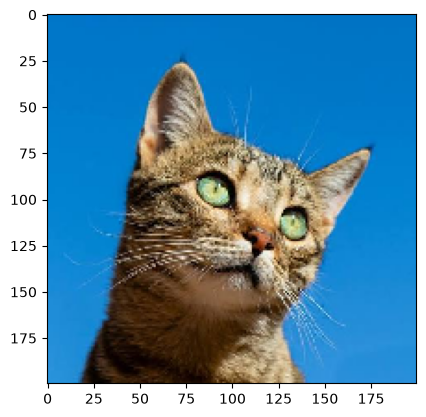

In [55]:
plt.imshow(img)

In [56]:
type(img)

PIL.Image.Image

**We have to change to image to the numpy array** 

In [57]:
# Convert image to array
image = keras.utils.img_to_array(img)

In [58]:
image

array([[[  0., 118., 200.],
        [  0., 118., 200.],
        [  0., 118., 200.],
        ...,
        [  0., 115., 196.],
        [  0., 115., 196.],
        [  0., 115., 196.]],

       [[  0., 118., 200.],
        [  0., 118., 200.],
        [  0., 118., 200.],
        ...,
        [  0., 115., 196.],
        [  0., 115., 196.],
        [  0., 115., 196.]],

       [[  0., 118., 200.],
        [  0., 118., 200.],
        [  0., 118., 200.],
        ...,
        [  0., 115., 196.],
        [  0., 115., 196.],
        [  0., 115., 196.]],

       ...,

       [[ 42., 149., 221.],
        [ 40., 147., 219.],
        [ 40., 147., 219.],
        ...,
        [ 40., 142., 217.],
        [ 40., 142., 217.],
        [ 40., 142., 217.]],

       [[ 42., 149., 221.],
        [ 40., 147., 219.],
        [ 40., 147., 219.],
        ...,
        [ 41., 143., 218.],
        [ 41., 143., 218.],
        [ 41., 143., 218.]],

       [[ 42., 149., 221.],
        [ 40., 147., 219.],
        [ 40., 1

In [59]:
type(image)

numpy.ndarray

In [60]:
image.shape

(200, 200, 3)

In [61]:
input_batch = image.reshape(1,200,200,3)

**Key point: We add the 4th dimension because CNNs expect image input in batch format: (batch, height, width, channels).and here we experiment with the one**


In [62]:
# Create augmentation model
#datagen = keras.Sequential([
    #keras.layers.RandomFlip("horizontal"),
    ##keras.layers.RandomFlip(0.2),
    #keras.layers.RandomZoom(0.2),
    #keras.layers.RandomTranslation(0.1, 0.1)
#])
# You can create also like that 

In [63]:
from keras import Sequential
from keras.layers import RandomFlip,RandomZoom,RandomTranslation,RandomRotation,RandomBrightness

In [16]:
model = Sequential()

model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomTranslation(0.1, 0.1))
model.add(RandomBrightness(0.2))

In [17]:
# Create folder
os.makedirs("augument_image", exist_ok=True)

In [18]:
# Generate 10 augmented images
for i in range(10):

    output = model(input_batch, training=True)

    keras.utils.save_img(
        f"augument_image/aug_{i+1}.jpg",
        output[0]
    )
#training=True tells them to actually perform the random augmentation.
#training=False. Keras augmentation layers, the random augmentation is not applied 

# Model with 1000 image without Augmentation

In [19]:
import tensorflow as tf
from tensorflow import keras

**If you put a dog image inside the cat folder, Keras will treat it as a cat.**

**subset tells Keras which part of the dataset you want to load when you have specified validation_split.**

*1000 images
│
├── 80% → 800 images
└── 20% → 200 images*


**validation_split = "Make a 20% validation portion from the original dataset."**

**subset = "Give me either the 80% training portion or the 20% validation portion from the same dataset**

In [20]:
# Load dataset
#Training Dataset 
train_ds = keras.utils.image_dataset_from_directory(
    "train",
    image_size=(200, 200),# use have to set the image size default is (256,256)
    batch_size=32,
    validation_split=0.2,
    subset="training",#Give me the 80% training portion.
    seed=42
)
# It label the image with the floder folder cat = 0 and floder dog = 1 

Found 2000 files belonging to 2 classes.
Using 1600 files for training.


In [21]:
val_ds = keras.utils.image_dataset_from_directory(
    "train",
    image_size=(200, 200),#image size default is (256,256) so u have to set the size or it give error 
    validation_split=0.2,
    subset="validation",# give me 20 % for the validation of the dataset from the same dataset. same dataset only change the subset to validation 
    seed=42
)
# seed is for the fix randomness 

Found 2000 files belonging to 2 classes.
Using 400 files for validation.


Rescaling(1./255) is used to normalize image pixel values before giving them to the CNN.
Rescaling(1./255) = convert image pixel values from 0–255 to 0–1. 

The Rescaling layer internally applies the scaling to whatever input it receives.

new_value = old_value × (1/255)

old value = 100

new_value = 100 × (1/255) = 0.392

**Rescaling(1/255) does not change the number of pixels or the image dimensions. It only changes the numerical values stored in those pixels.**

**For example, suppose an image has these pixel values:**

    Original pixel values:

    255    40    143    10    0

    keras.layers.Rescaling(1/255)

    255 / 255 = 1.000
    
     40 / 255 = 0.157
     
    143 / 255 = 0.561
    
     10 / 255 = 0.039
     
      0 / 255 = 0.000

    Before              After

    255    ──────────→   1.000
     40    ──────────→   0.157
    143    ──────────→   0.561
     10    ──────────→   0.039
      0    ──────────→   0.000

    The pixels are still in the same positions and the image shape is unchanged:

    Before:  (200, 200, 3)
    
    After:   (200, 200, 3)

In [22]:
from keras import Sequential
from keras.layers import MaxPooling2D,Conv2D,Rescaling,Dense,Flatten,Input

In [23]:
model = Sequential()
# CNN
model.add(Input(shape=(200, 200, 3)))
model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128, activation="relu"))

# Cat = 0, Dog = 1
model.add(Dense(1, activation="sigmoid"))

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 198, 198, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 99, 99, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 97, 97, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 46, 46, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 67712)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       8,667,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,281,925 (100.26 MB)

 Trainable params: 8,760,641 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,521,284 (66.84 MB)

In [25]:
# Compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [26]:
# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


C:\Users\rkmou\OneDrive\Desktop\jypter\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 396ms/step - accuracy: 0.4956 - loss: 38.3649 - val_accuracy: 0.4725 - val_loss: 0.6901
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.5987 - loss: 0.6599 - val_accuracy: 0.5675 - val_loss: 0.6799
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 439ms/step - accuracy: 0.7175 - loss: 0.5524 - val_accuracy: 0.6025 - val_loss: 0.7402
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 415ms/step - accuracy: 0.7669 - loss: 0.4778 - val_accuracy: 0.5775 - val_loss: 0.8200
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.8381 - loss: 0.3524 - val_accuracy: 0.5450 - val_loss: 1.3036
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 405ms/step - accuracy: 0.8875 - loss: 0.2503 - val_accuracy: 0.5750 - val_loss: 1.3340
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 0.9344 - loss: 0.1658 - val_accuracy: 0.5375 - val_loss: 2.0277
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 758ms/step - accuracy: 0.9669 - loss: 0.0942 - val_accuracy: 0.57

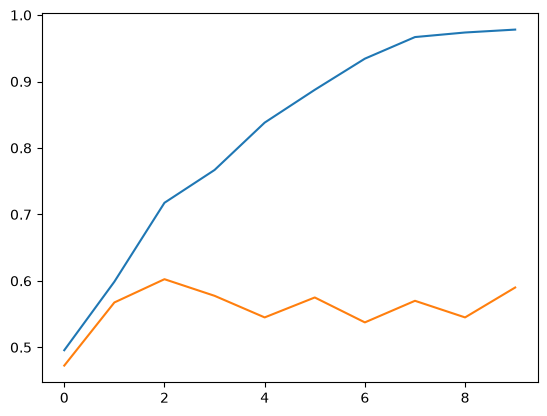

In [31]:
import matplotlib.pyplot as plt 
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
# This is overfitting we have to improve the val accuracy

# Without Augmentation val_accuracy is 59 % 

# Model with the data Augmentation of the dataset with 1000 image 

In [49]:
# Load dataset
#Training Dataset 
train_aug = keras.utils.image_dataset_from_directory(
    "train with augementation",
    image_size=(200, 200),# use have to set the image size default is (256,256)
    batch_size=32,
    validation_split=0.2,
    subset="training",#Give me the 80% training portion.
    seed=42
)
# It label the image with the floder folder cat = 0 and floder dog = 1 

Found 2000 files belonging to 2 classes.
Using 1600 files for training.


In [44]:
from keras.layers import RandomFlip,RandomRotation,RandomZoom,RandomTranslation,RandomBrightness,Rescaling,Input
# Data augmentation
model_1 = Sequential()

model_1.add(Input(shape=(200, 200, 3)))

# it is taking random image applied all the thing flip,zoom, brightness. but u have not write code to save the image in the folder
model_1.add(RandomFlip("horizontal"))
model_1.add(RandomRotation(0.2))
model_1.add(RandomZoom(0.2))
model_1.add(RandomTranslation(0.1, 0.1))
model_1.add(RandomBrightness(0.2))

In [45]:
#Rescaling
model_1.add(Rescaling(1./255))

In [46]:
# CNNS
model_1.add(Conv2D(32, (3, 3), activation="relu"))
model_1.add(MaxPooling2D())

model_1.add(Conv2D(64, (3, 3), activation="relu"))
model_1.add(keras.layers.MaxPooling2D())

model_1.add(Conv2D(128, (3, 3), activation="relu"))
model_1.add(MaxPooling2D())

model_1.add(Flatten())

model_1.add(Dense(128, activation="relu"))

# Cat = 0, Dog = 1
model_1.add(Dense(1, activation="sigmoid"))
model_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)           │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_4 (RandomRotation)   │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_4 (RandomZoom)           │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_translation_4                 │ (None, 200, 200, 3)         │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_brightness_4                  │ (None, 200, 200, 3)         │               0 │
│ (RandomBrightness)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_4 (Rescaling)              │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 198, 198, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 99, 99, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 97, 97, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 46, 46, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 67712)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │       8,667,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,760,641 (33.42 MB)

 Trainable params: 8,760,641 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Compile
model_1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [50]:
# Train
history = model_1.fit(
    train_aug,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.4994 - loss: 0.6926 - val_accuracy: 0.5600 - val_loss: 0.6851
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 988ms/step - accuracy: 0.5369 - loss: 0.6888 - val_accuracy: 0.6125 - val_loss: 0.6688
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5881 - loss: 0.6744 - val_accuracy: 0.6175 - val_loss: 0.6682
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6137 - loss: 0.6573 - val_accuracy: 0.6225 - val_loss: 0.6579
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 762ms/step - accuracy: 0.6500 - loss: 0.6319 - val_accuracy: 0.6125 - val_loss: 0.7483
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 449ms/step - accuracy: 0.6400 - loss: 0.6428 - val_accuracy: 0.6475 - val_loss: 0.6091
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 472ms/step - accuracy: 0.6531 - loss: 0.6246 - val_accuracy: 0.5875 - val_loss: 0.6497
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 469ms/step - accuracy: 0.6581 - loss: 0.6254 - val_accuracy: 0.6

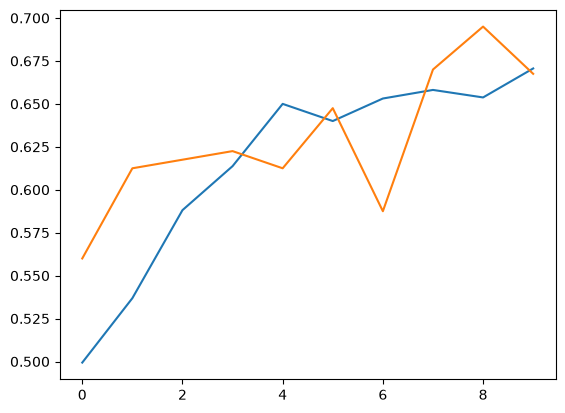

In [51]:
import matplotlib.pyplot as plt 
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
# This is overfitting we have to improve the val accuracy

# With Augmentation val_accuracy is 67 %